# 1. Data Loading & Exploration
Importing necessary libraries and loading the dataset.

In [10]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')


In [11]:
data = pd.read_csv("dailyActivity_merged.csv")

# 2. Data Cleaning & Preprocessing
Checking for missing values, duplicates, and fixing data types.

In [12]:
data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [13]:
data.shape

(940, 15)

In [14]:
data.Id.nunique()

33

In [15]:
cols =['Id','ActivityDate','TotalSteps','VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes','Calories']

df = data[cols]

In [16]:
df.rename(columns={'ActivityDate':'Date'},inplace=True)

In [17]:
df['TotalMinutes']=df.VeryActiveMinutes + df.FairlyActiveMinutes + df.LightlyActiveMinutes + df.SedentaryMinutes

In [18]:
df['TotalHours']=round(df.TotalMinutes / 60)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    940 non-null    int64  
 1   Date                  940 non-null    object 
 2   TotalSteps            940 non-null    int64  
 3   VeryActiveMinutes     940 non-null    int64  
 4   FairlyActiveMinutes   940 non-null    int64  
 5   LightlyActiveMinutes  940 non-null    int64  
 6   SedentaryMinutes      940 non-null    int64  
 7   Calories              940 non-null    int64  
 8   TotalMinutes          940 non-null    int64  
 9   TotalHours            940 non-null    float64
dtypes: float64(1), int64(8), object(1)
memory usage: 73.6+ KB


In [20]:
df.Date=pd.to_datetime(df.Date)
df.Date.dtypes

dtype('<M8[ns]')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    940 non-null    int64         
 1   Date                  940 non-null    datetime64[ns]
 2   TotalSteps            940 non-null    int64         
 3   VeryActiveMinutes     940 non-null    int64         
 4   FairlyActiveMinutes   940 non-null    int64         
 5   LightlyActiveMinutes  940 non-null    int64         
 6   SedentaryMinutes      940 non-null    int64         
 7   Calories              940 non-null    int64         
 8   TotalMinutes          940 non-null    int64         
 9   TotalHours            940 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(8)
memory usage: 73.6 KB


In [22]:
df['DayOfWeek'] = df.Date.dt.day_name()

In [23]:
df.isna().sum()

Id                      0
Date                    0
TotalSteps              0
VeryActiveMinutes       0
FairlyActiveMinutes     0
LightlyActiveMinutes    0
SedentaryMinutes        0
Calories                0
TotalMinutes            0
TotalHours              0
DayOfWeek               0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

# 3. Feature Engineering
Creating new features to enrich the dataset for modeling.

In [25]:
df['ActiveMinutesRatio'] = (df['VeryActiveMinutes'] + df['FairlyActiveMinutes']) / df['TotalMinutes']
df['StepsPerActiveMinute'] = df['TotalSteps'] / (df['VeryActiveMinutes'] + df['FairlyActiveMinutes'] + df['LightlyActiveMinutes'] + 1e-5)
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)
df['CaloriesPerStep'] = df['Calories'] / (df['TotalSteps'] + 1e-5)
df['ActivityIntensity'] = df['VeryActiveMinutes'] * 3 + df['FairlyActiveMinutes'] * 2 + df['LightlyActiveMinutes'] * 1
df['ReachedGoal'] = (df['TotalSteps'] >= 10000).astype(int)
df.head()

,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours,DayOfWeek,ActiveMinutesRatio,StepsPerActiveMinute,IsWeekend,CaloriesPerStep,ActivityIntensity,ReachedGoal
0,1503960366,2016-04-12,13162,25,13,328,728,1985,1094,18.0,Tuesday,0.034735,35.961748,0,0.150813,429,1
1,1503960366,2016-04-13,10735,21,19,217,776,1797,1033,17.0,Wednesday,0.038722,41.770426,0,0.167396,318,1
2,1503960366,2016-04-14,10460,30,11,181,1218,1776,1440,24.0,Thursday,0.028472,47.117115,0,0.169790,293,1
3,1503960366,2016-04-15,9762,29,34,209,726,1745,998,17.0,Friday,0.063126,35.889705,0,0.178754,364,0
4,1503960366,2016-04-16,12669,36,10,221,773,1863,1040,17.0,Saturday,0.044231,47.449436,1,0.147052,349,1


# 4. Exploratory Data Analysis (EDA)
Visualizing distributions and relationships.

In [26]:
df.describe()

,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours,ActiveMinutesRatio,StepsPerActiveMinute,IsWeekend,CaloriesPerStep,ActivityIntensity,ReachedGoal
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,9.400000e+02,940.000000,9.400000e+02,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,21.164894,13.564894,192.812766,991.210638,2303.609574,1218.753191,20.313830,0.030340,5.348328e+06,0.260638,1.357394e+07,283.437234,0.322340
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,0.000000,0.000000,127.000000,729.750000,1828.500000,989.750000,16.000000,0.000000,2.090191e+01,0.000000,2.258734e-01,163.500000,0.000000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,4.000000,6.000000,199.000000,1057.500000,2134.000000,1440.000000,24.000000,0.016676,2.924055e+01,0.000000,3.134340e-01,300.000000,0.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000,1440.000000,24.000000,0.048222,3.922288e+01,1.000000,5.034211e-01,398.250000,1.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,210.000000,143.000000,518.000000,1440.000000,4900.000000,1440.000000,24.000000,0.326992,1.201500e+09,1.000000,2.664000e+08,904.000000,1.000000
std,2.424805e+09,NaN,5087.150742,32.844803,19.987404,109.174700,301.267437,718.166862,265.931767,4.437283,0.040432,6.736900e+07,0.439217,4.815013e+07,167.640880,0.467621


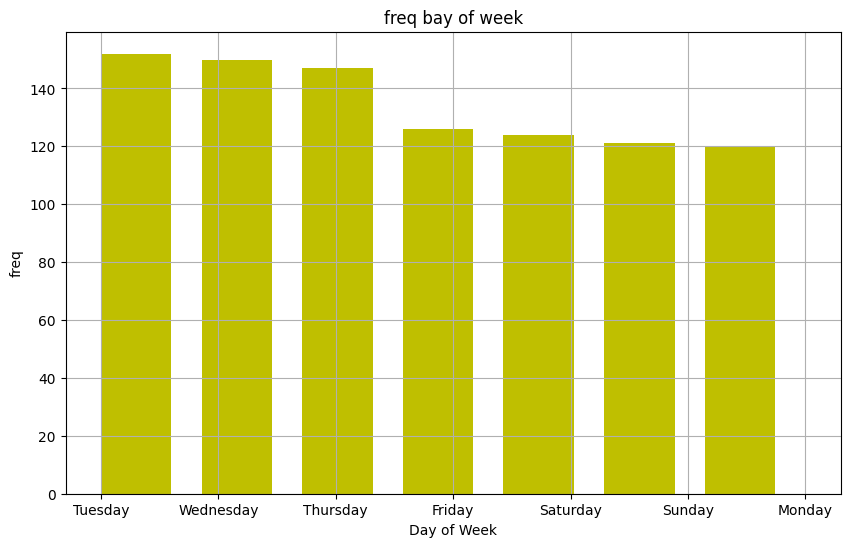

In [27]:
plt.figure(figsize=((10,6)))
plt.hist(df.DayOfWeek,color='y',bins=7,width =.6,align='mid')

plt.xlabel('Day of Week')
plt.ylabel('freq')
plt.title('freq bay of week')

plt.grid()
plt.show()

In [28]:
mask = df.drop(['DayOfWeek','Date'],axis=1)

In [29]:
mask.corr()

,Id,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours,ActiveMinutesRatio,StepsPerActiveMinute,IsWeekend,CaloriesPerStep,ActivityIntensity,ReachedGoal
Id,1.000000,0.185721,0.303608,0.051158,-0.098754,-0.043319,0.396671,-0.048274,-0.048140,0.227114,0.072959,0.005591,-0.020151,0.126338,0.141633
TotalSteps,0.185721,1.000000,0.667079,0.498693,0.569600,-0.327484,0.591568,-0.017285,-0.018152,0.651544,0.013944,-0.010199,-0.423712,0.881953,0.773114
VeryActiveMinutes,0.303608,0.667079,1.000000,0.312420,0.051926,-0.164671,0.615838,-0.018244,-0.021064,0.856071,-0.051211,-0.003647,-0.175933,0.696085,0.575233
FairlyActiveMinutes,0.051158,0.498693,0.312420,1.000000,0.148820,-0.237446,0.297623,-0.094155,-0.094941,0.680103,-0.053936,0.038771,-0.191527,0.519004,0.476715
LightlyActiveMinutes,-0.098754,0.569600,0.051926,0.148820,1.000000,-0.437104,0.286718,-0.067049,-0.066640,0.074272,-0.140356,-0.011152,-0.498407,0.717249,0.284632
SedentaryMinutes,-0.043319,-0.327484,-0.164671,-0.237446,-0.437104,1.000000,-0.106973,0.915243,0.914539,-0.350031,0.118388,-0.027804,0.409628,-0.438069,-0.234892
Calories,0.396671,0.591568,0.615838,0.297623,0.286718,-0.106973,1.000000,0.094951,0.093314,0.544252,0.053457,0.004911,-0.181421,0.619664,0.422745
TotalMinutes,-0.048274,-0.017285,-0.018244,-0.094155,-0.067049,0.915243,0.094951,1.000000,0.998963,-0.209202,0.066119,-0.033613,0.223318,-0.076840,-0.042376
TotalHours,-0.048140,-0.018152,-0.021064,-0.094941,-0.066640,0.914539,0.093314,0.998963,1.000000,-0.212252,0.066020,-0.032179,0.222977,-0.078419,-0.043672
ActiveMinutesRatio,0.227114,0.651544,0.856071,0.680103,0.074272,-0.350031,0.544252,-0.209202,-0.212252,1.000000,-0.059635,0.024676,-0.208425,0.713716,0.604772


<Axes: >

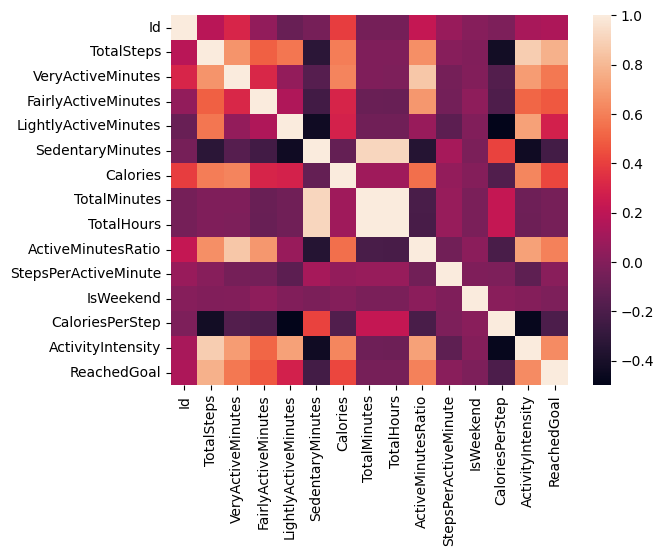

In [30]:
sns.heatmap(mask.corr())

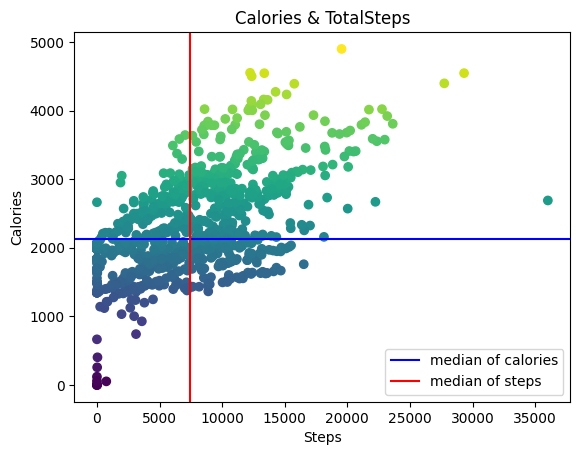

In [31]:
plt.scatter(mask.TotalSteps,mask.Calories,c=mask.Calories )

median_steps = 7405
median_calories = 2134

plt.axhline(median_calories,color = 'b',label = 'median of calories')
plt.axvline(median_steps,color = 'r',label = 'median of steps')

plt.xlabel('Steps')
plt.ylabel('Calories')
plt.title('Calories & TotalSteps')

plt.legend()
plt.show()

In [32]:
print(mask.columns)


Index(['Id', 'TotalSteps', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'TotalMinutes',
       'TotalHours', 'ActiveMinutesRatio', 'StepsPerActiveMinute', 'IsWeekend',
       'CaloriesPerStep', 'ActivityIntensity', 'ReachedGoal'],
      dtype='object')


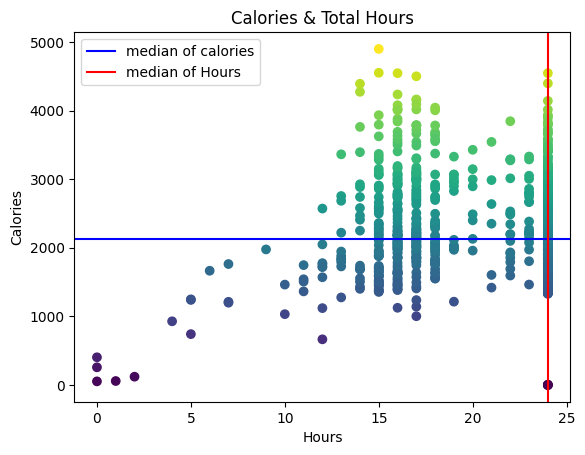

In [33]:
plt.scatter(mask.TotalHours,mask.Calories,c=mask.Calories )

median_Hours = 24
median_calories = 2134

plt.axhline(median_calories,color = 'b',label = 'median of calories')
plt.axvline(median_Hours,color = 'r',label = 'median of Hours')

plt.xlabel('Hours')
plt.ylabel('Calories')
plt.title('Calories & Total Hours')

plt.legend()
plt.show()

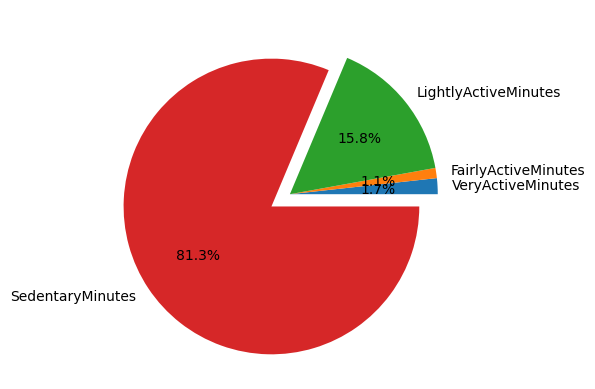

In [34]:
minutes = [df.VeryActiveMinutes.sum(),df.FairlyActiveMinutes.sum(),
           df.LightlyActiveMinutes.sum(),df.SedentaryMinutes.sum()
          ]
labels = ['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']

plt.pie(minutes,labels=labels,autopct='%1.1f%%',explode=[0,0,0,0.15])

plt.show()

# 5. Unsupervised Learning — K-Means Clustering
Clustering users into 3 groups based on activity levels.

In [35]:
from sklearn.cluster import KMeans
X_cluster = df[['TotalSteps', 'Calories']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)
df['Cluster'].value_counts()

Cluster
2    419
0    344
1    177
Name: count, dtype: int64

# 6. Supervised Learning — Classification Pipeline
Predicting if a user will reach their daily step goal.

In [36]:
from sklearn.model_selection import train_test_split

features = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes',
            'SedentaryMinutes', 'Calories', 'ActiveMinutesRatio',
            'IsWeekend', 'ActivityIntensity']

X = df[features]
y = df['ReachedGoal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

# 7. Model Evaluation & Comparison
Evaluating the Logistic Regression model and comparing with others.

Accuracy: 86.70%
               precision    recall  f1-score   support

Did Not Reach       0.95      0.85      0.90       127
 Reached Goal       0.74      0.90      0.81        61

     accuracy                           0.87       188
    macro avg       0.85      0.88      0.86       188
 weighted avg       0.88      0.87      0.87       188



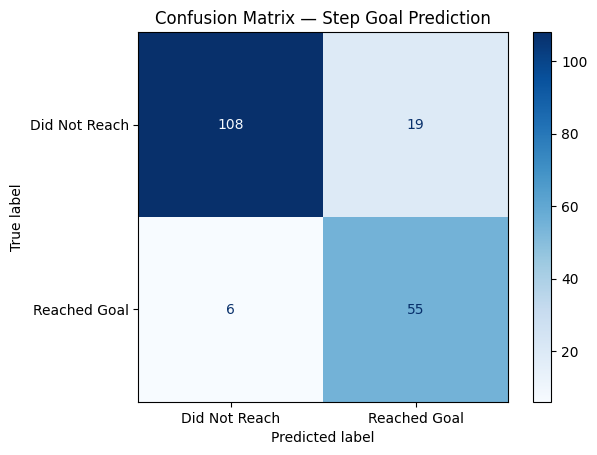

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred, target_names=['Did Not Reach', 'Reached Goal']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Did Not Reach', 'Reached Goal'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Step Goal Prediction')
plt.show()

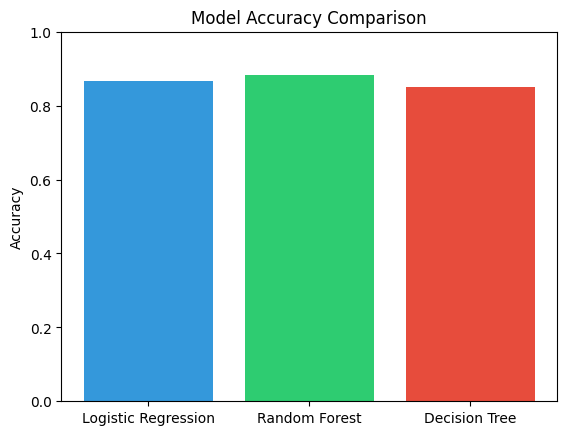

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

plt.bar(results.keys(), results.values(), color=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

best_model_name = max(results, key=results.get)
best_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', models[best_model_name])])
best_pipeline.fit(X_train, y_train)

# 8. Model Export
Saving the model and processed data.

In [40]:
import joblib
import json

joblib.dump(best_pipeline, 'step_goal_model.pkl')
df.to_csv('preprocessed_dailyActivity.csv', index=False)

with open('metrics.json', 'w') as f:
    json.dump(results, f)